# Exploratory Data Analysis (EDA)
This notebook performs exploratory data analysis on the student performance dataset.

## Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Load cleaned dataset
df = pd.read_csv('cleaned_dataset.csv')

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset shape: (15000, 15)
Columns: ['age', 'gender', 'school_type', 'parent_education', 'study_hours', 'attendance_percentage', 'internet_access', 'travel_time', 'extra_activities', 'study_method', 'computer_network_score', 'operating_system_score', 'daa_score', 'overall_score', 'final_grade']


## Identify Categorical and Numerical Columns

In [2]:
# Separate features and target
X = df.drop('final_grade', axis=1)
y = df['final_grade']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['gender', 'school_type', 'parent_education', 'internet_access', 'travel_time', 'extra_activities', 'study_method']
Numerical columns: ['age', 'study_hours', 'attendance_percentage', 'computer_network_score', 'operating_system_score', 'daa_score', 'overall_score']


C:\Users\prama\AppData\Local\Temp\ipykernel_30528\1326502596.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


## Prepare Data for Visualization

In [3]:
# Encode categorical variables for correlation
le = LabelEncoder()
X_encoded = X.copy()
for col in categorical_cols:
    X_encoded[col] = le.fit_transform(X_encoded[col])

y_encoded = le.fit_transform(y)

# Combine for correlation
df_encoded = X_encoded.copy()
df_encoded['final_grade'] = y_encoded

print("Data prepared for visualization")

Data prepared for visualization


## Correlation Heatmap

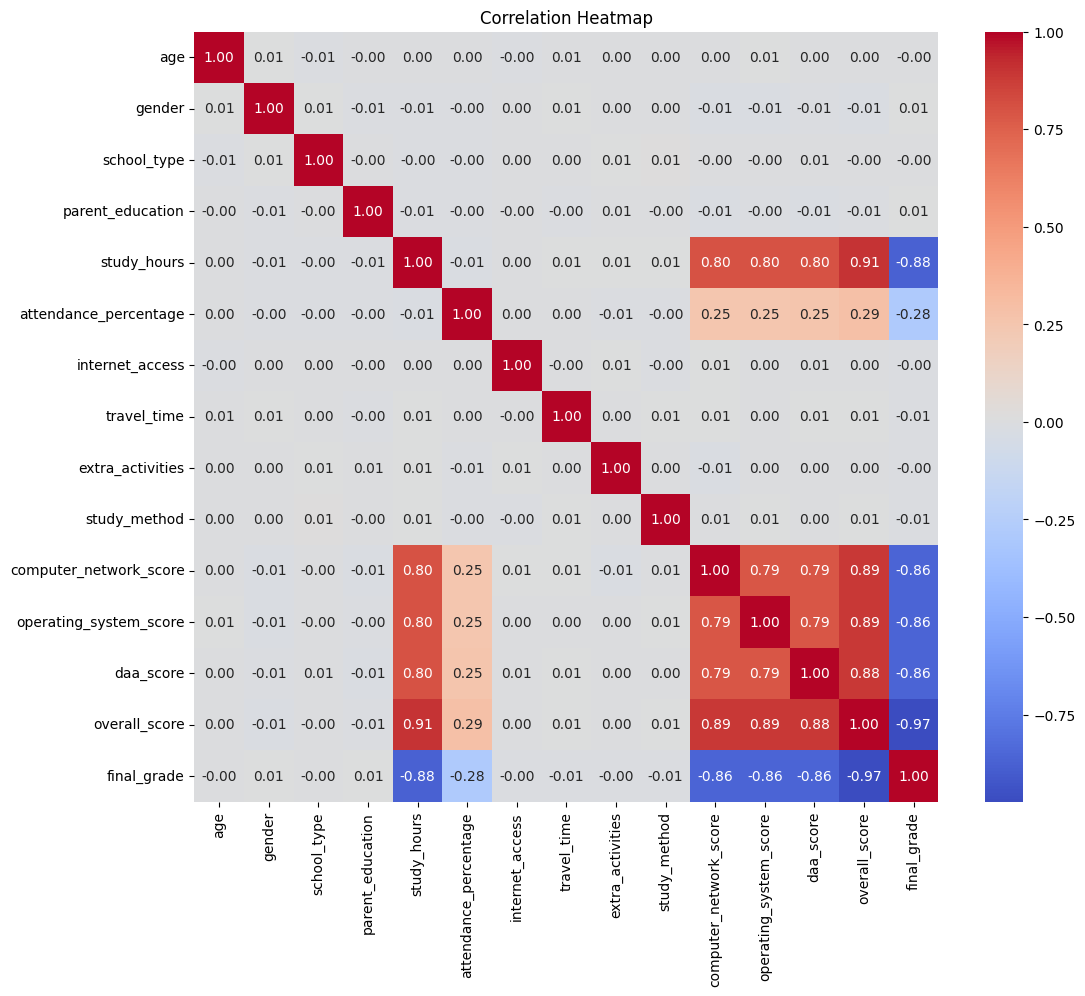

In [4]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')
plt.show()

## Distribution of Numerical Features

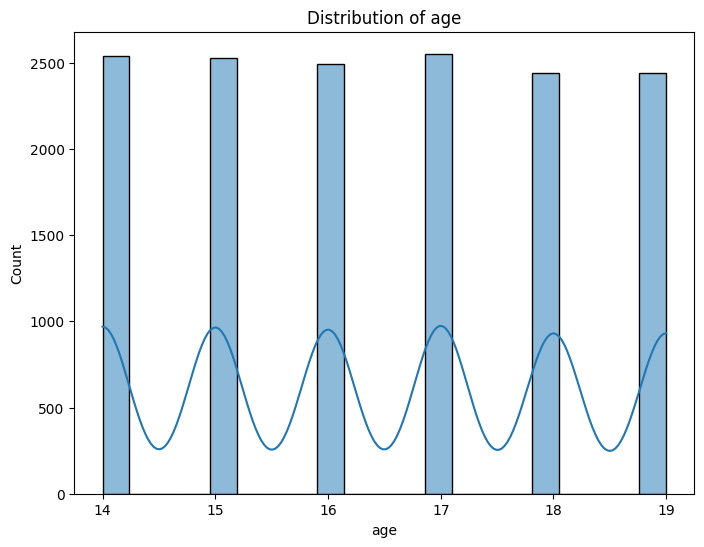

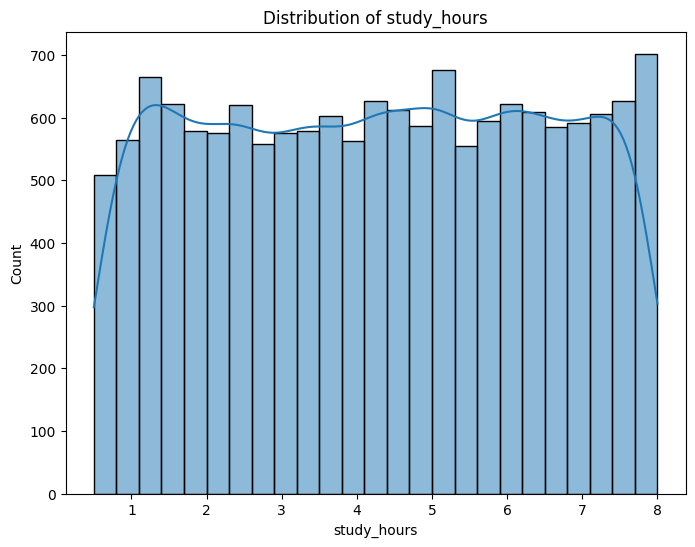

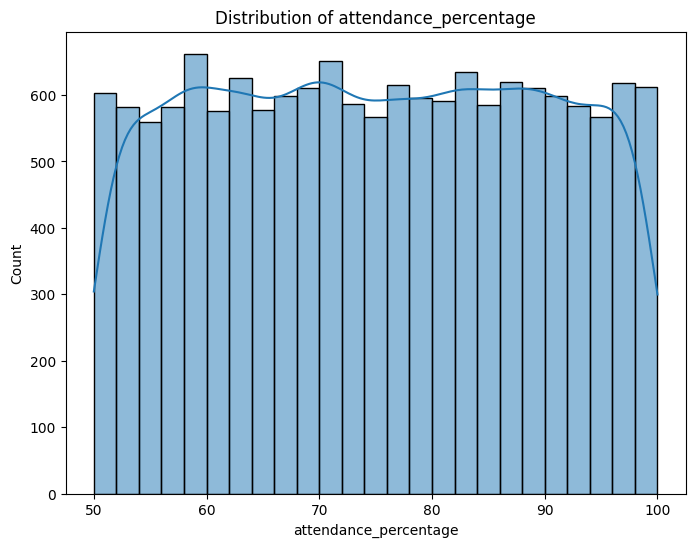

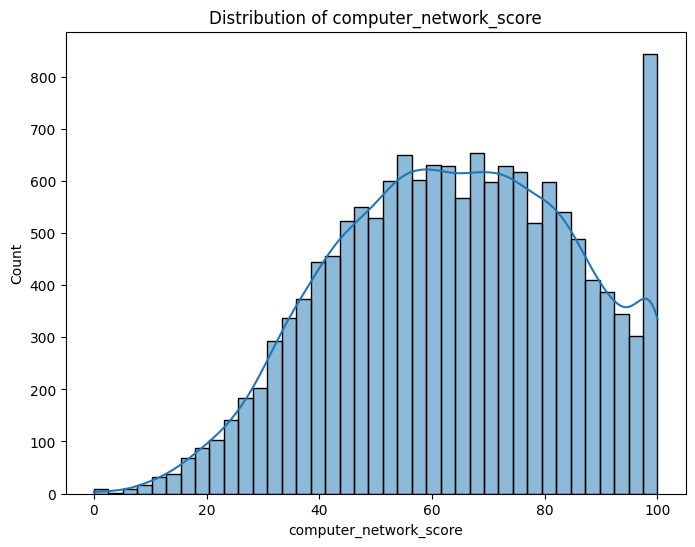

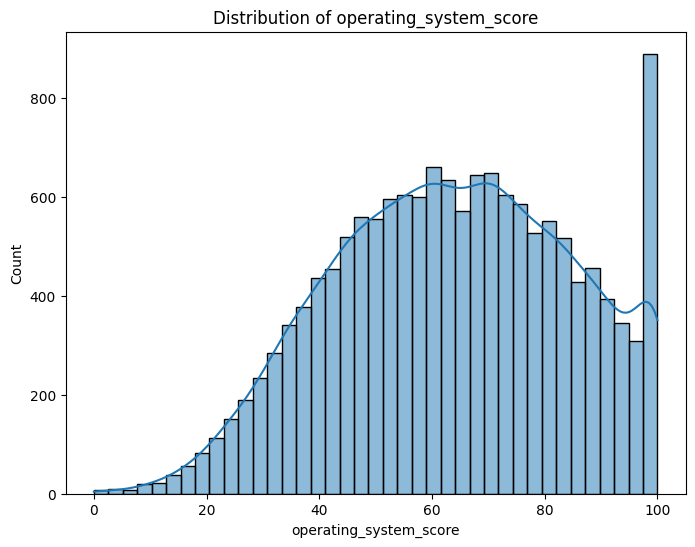

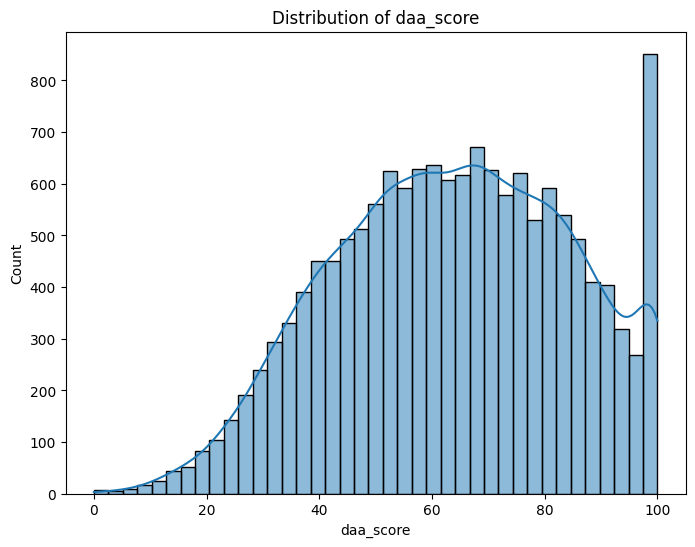

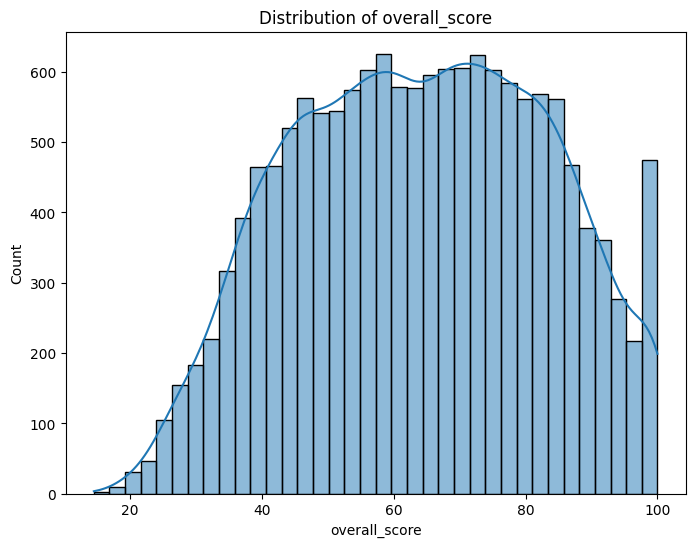

In [5]:
# Plot distributions for numerical features
for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.savefig(f'{col}_distribution.png')
    plt.show()

## Boxplots for Numerical Features vs Target

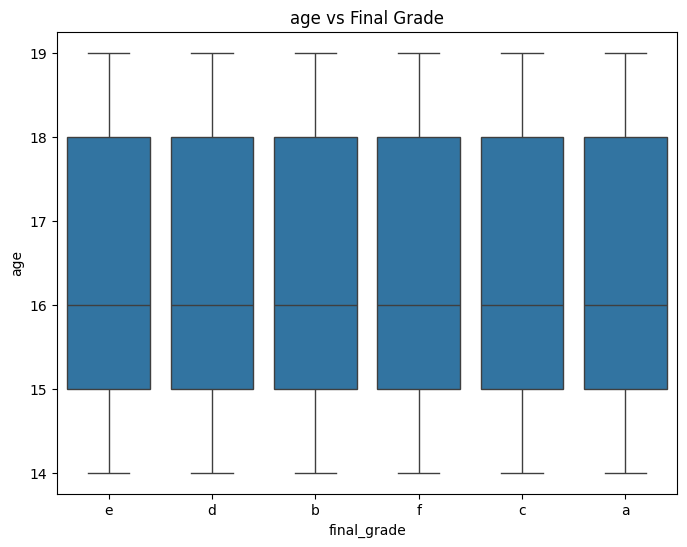

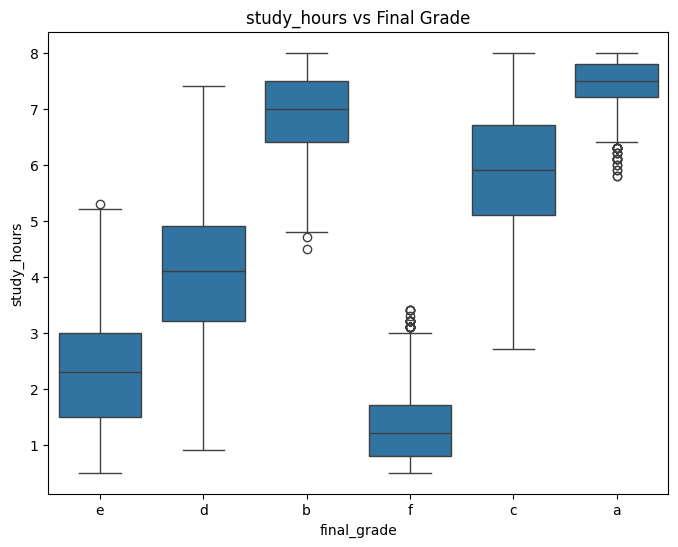

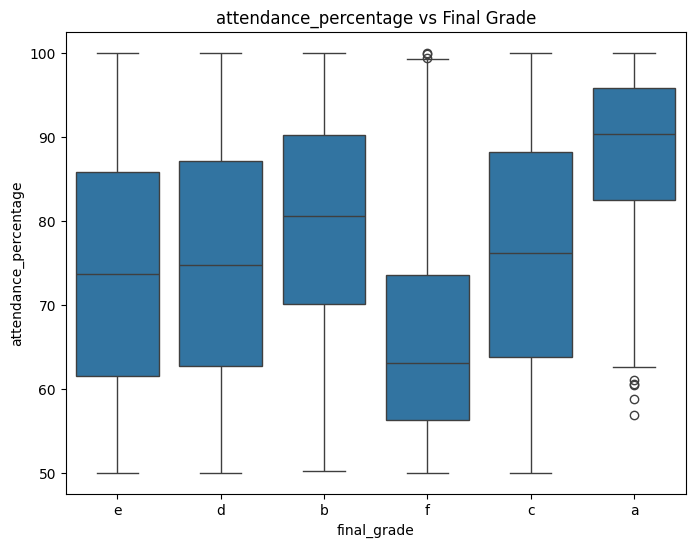

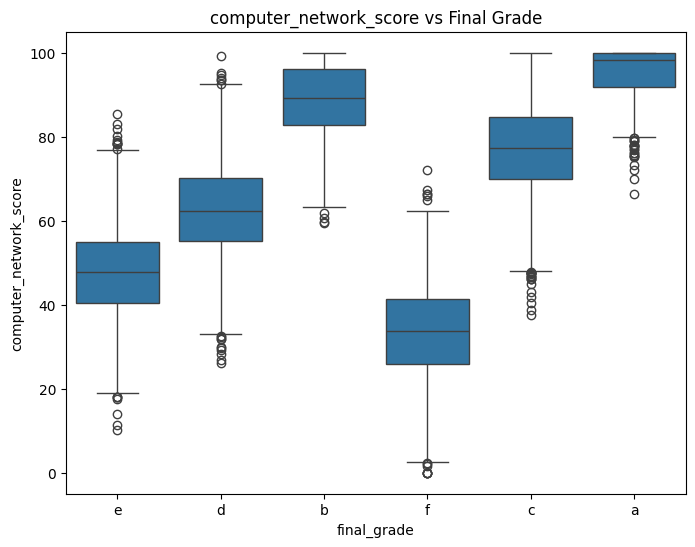

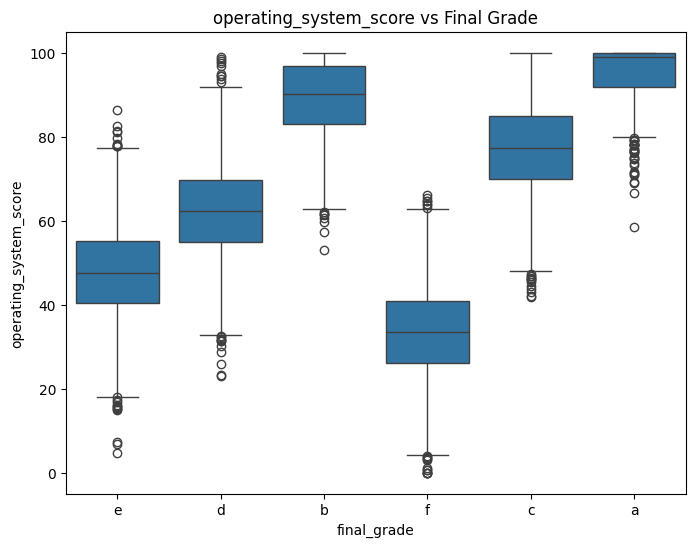

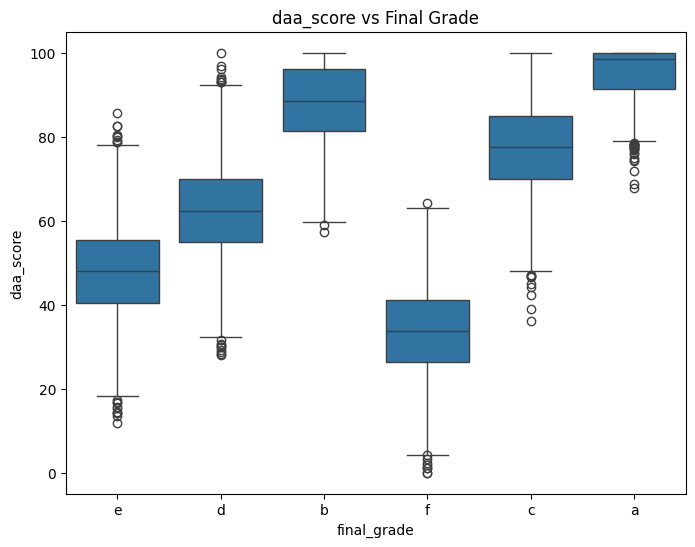

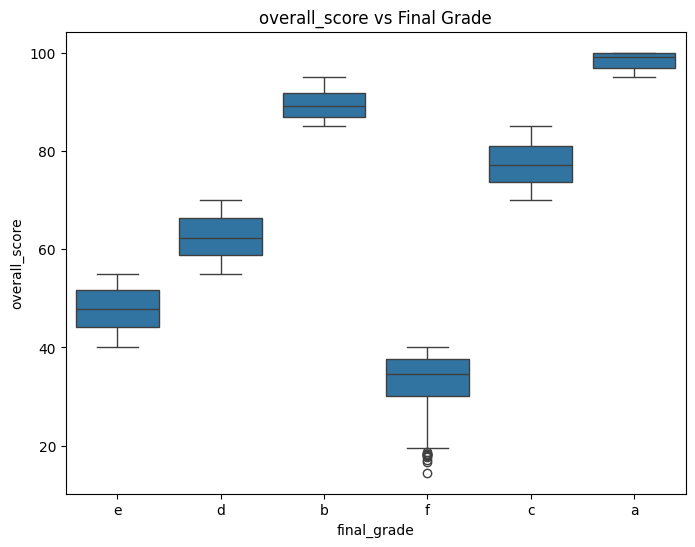

In [6]:
# Boxplots for numerical features vs target
for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='final_grade', y=col, data=df)
    plt.title(f'{col} vs Final Grade')
    plt.savefig(f'{col}_vs_grade.png')
    plt.show()

## Count Plots for Categorical Features

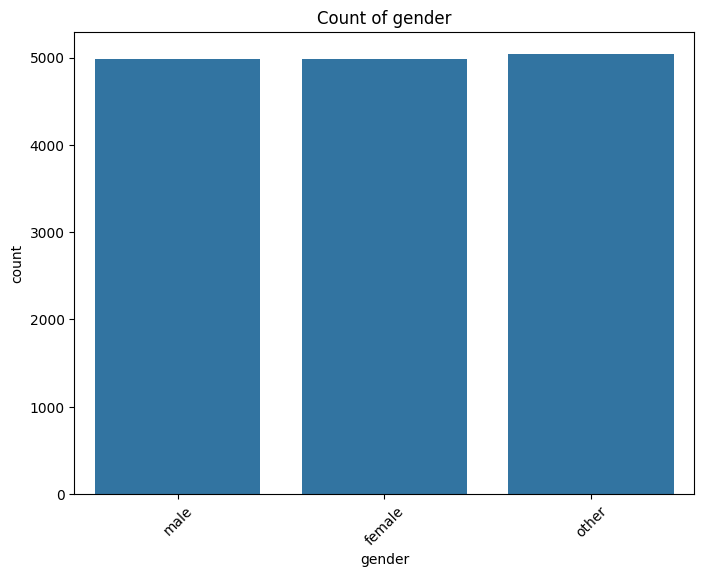

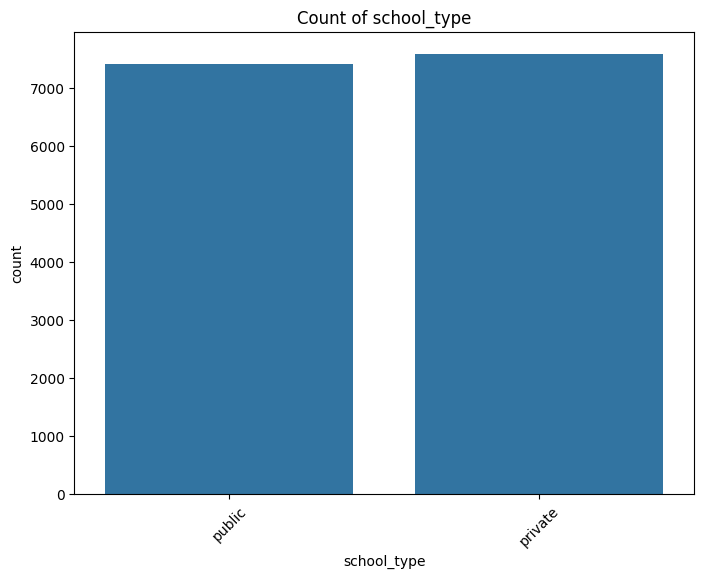

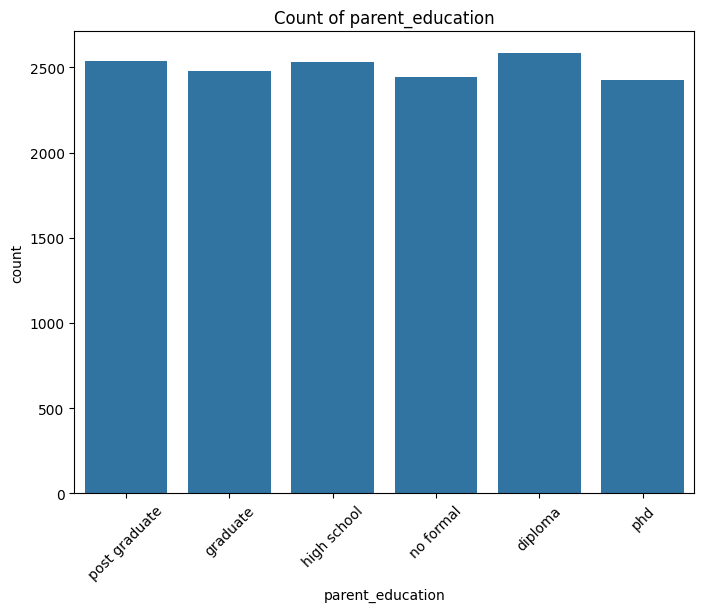

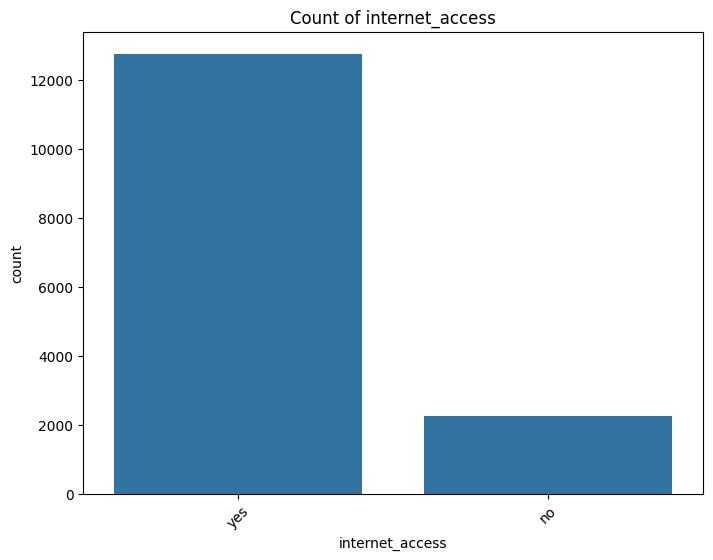

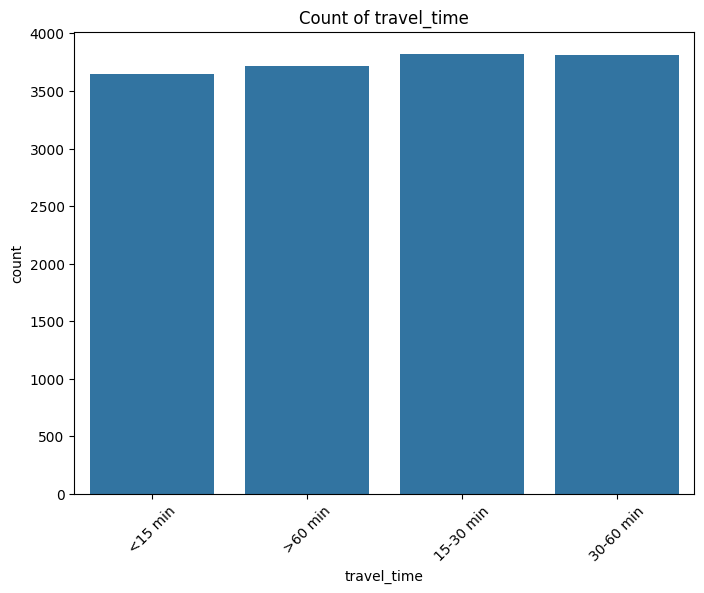

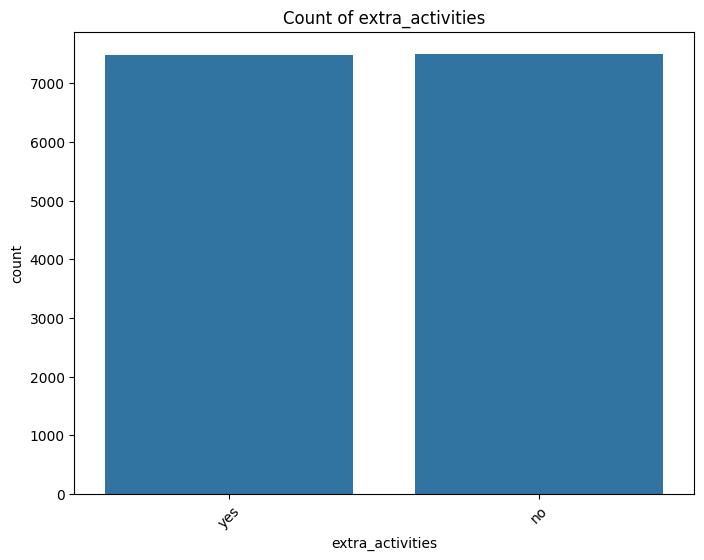

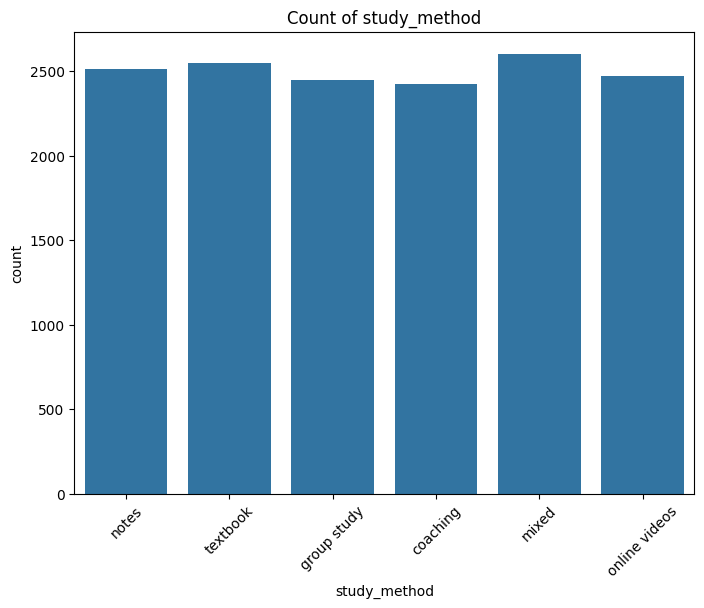

In [7]:
# Count plots for categorical features
for col in categorical_cols:
    plt.figure(figsize=(8, 6))
    sns.countplot(x=col, data=df)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
    plt.savefig(f'{col}_count.png')
    plt.show()

## Feature Engineering: One-Hot Encoding

In [8]:
# Feature engineering: One-hot encode categorical variables
X_processed = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Save processed data
X_processed['final_grade'] = y
X_processed.to_csv('processed_dataset.csv', index=False)

print("Processed dataset saved as 'processed_dataset.csv'")
print("Processed features shape:", X_processed.shape)

Processed dataset saved as 'processed_dataset.csv'
Processed features shape: (15000, 26)
